## IMPORT FILES & Data

In [2]:

import os
import numpy as np
import pandas as pd
from biom import load_table
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

In [3]:
processed_data ="E:\\curahack-2026-challenge-5\\datasets\\datasets\\processed"

In [4]:
agp_meta ="E:\curahack-2026-challenge-5\datasets\datasets\processed\AGP\meta.tsv"
agp_otu ="E:\curahack-2026-challenge-5\datasets\datasets\processed\AGP\otu.tsv"
ggmp_meta ="E:\curahack-2026-challenge-5\datasets\datasets\processed\GGMP\meta.tsv"
ggmp_otu ="E:\curahack-2026-challenge-5\datasets\datasets\processed\GGMP\otu.tsv"

In [5]:
meta_path = "E:\\curahack-2026-challenge-5\\datasets\\datasets\\processed\\AGP\\meta.tsv"
otu_path = "E:\\curahack-2026-challenge-5\\datasets\\datasets\\processed\\AGP\\otu.tsv"
output_dir = "E:\\curahack-2026-challenge-5\\datasets\\datasets\\processed\\output"

In [6]:
meta_df = pd.read_csv(meta_path, sep='\t')
otu_df = pd.read_csv(otu_path, sep='\t')

In [7]:
meta_df.head()

,id,age,health
0,10317.X00183724.116729,47.9,y
1,10317.X00185611.139047,49.8,n
2,10317.X00185611.122331,49.8,n
3,10317.X00185611.137612,49.8,n
4,10317.000100524.62408,28.0,y


In [8]:
otu_df.head()

,id,2686384,105287,363430,174288,2046330,227565,4301511,191395,4459196,...,2985051,194380,174360,179159,3973322,4296763,563572,556835,195619,183650
0,10317.X00183724.116729,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,35.0,0.0,0.0,0.0,0.0,0.0
1,10317.X00185611.139047,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10317.X00185611.122331,0.0,0.0,0.0,7.0,0.0,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
3,10317.X00185611.137612,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10317.000100524.62408,0.0,1.0,0.0,29.0,7.0,1.0,37.0,0.0,291.0,...,2.0,1.0,10.0,0.0,1.0,0.0,1.0,0.0,7.0,0.0


In [9]:
print(otu_df.shape)
print(meta_df.shape)

(5965, 1330)
(5965, 3)


In [10]:
joined_df = pd.merge(otu_df, meta_df, left_on='id', right_on='id')

In [11]:
joined_df.shape

(5965, 1332)

### FEATURE EVALUATION AND SELECTION

In [12]:
joined_df.head()

,id,2686384,105287,363430,174288,2046330,227565,4301511,191395,4459196,...,174360,179159,3973322,4296763,563572,556835,195619,183650,age,health
0,10317.X00183724.116729,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,...,0.0,0.0,35.0,0.0,0.0,0.0,0.0,0.0,47.9,y
1,10317.X00185611.139047,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.8,n
2,10317.X00185611.122331,0.0,0.0,0.0,7.0,0.0,9.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,49.8,n
3,10317.X00185611.137612,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.8,n
4,10317.000100524.62408,0.0,1.0,0.0,29.0,7.0,1.0,37.0,0.0,291.0,...,10.0,0.0,1.0,0.0,1.0,0.0,7.0,0.0,28.0,y


Explained variance ratio of each component:
[1.59022236e-01 3.32632401e-02 2.68709777e-02 ... 5.41490061e-07
 4.90463672e-07 4.64589506e-07]


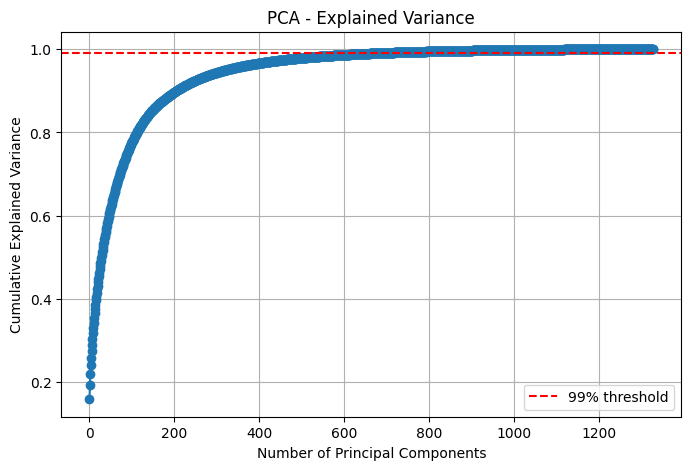

Number of components to explain 99% variance: 668


In [13]:
exclude_cols = ['id', 'age', 'health']
X = joined_df.loc[:, ~joined_df.columns.isin(exclude_cols)]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()  # keep all components
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio of each component:")
print(explained_variance)

cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.axhline(y=0.99, color='r', linestyle='--', label='99% threshold')
plt.grid(True)
plt.legend()
plt.show()


n_components = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Number of components to explain 99% variance: {n_components}")

pca_reduced = PCA(n_components=n_components)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

In [14]:
pca_columns = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca_reduced, columns=pca_columns)
df_pca.index = joined_df.index
df_pca_final = pd.concat([joined_df[exclude_cols], df_pca], axis=1)
print("Final PCA DataFrame:")

Final PCA DataFrame:


In [15]:
df_pca_final.head()

,id,age,health,PC1,PC2,PC3,PC4,PC5,PC6,PC7,...,PC659,PC660,PC661,PC662,PC663,PC664,PC665,PC666,PC667,PC668
0,10317.X00183724.116729,47.9,y,-3.945333,-0.347706,0.670558,0.389288,0.326644,-0.536694,-0.488975,...,-0.023759,-0.235375,-0.103490,-0.032113,0.372912,-0.056203,-0.227197,0.075027,0.302592,0.089843
1,10317.X00185611.139047,49.8,n,-4.676748,0.546782,-0.041431,0.567786,0.451542,0.391983,-0.107400,...,-0.000767,-0.027216,0.013714,0.003496,0.010072,0.017422,-0.009677,0.003383,0.023448,0.001598
2,10317.X00185611.122331,49.8,n,0.320833,0.744147,1.071563,0.142786,-1.014044,1.498571,1.355753,...,-0.031422,-0.251358,0.025115,-0.514379,-0.087546,-0.061765,0.239223,-0.254959,-0.140617,0.031780
3,10317.X00185611.137612,49.8,n,-4.676748,0.546782,-0.041431,0.567786,0.451542,0.391983,-0.107400,...,-0.000767,-0.027216,0.013714,0.003496,0.010072,0.017422,-0.009677,0.003383,0.023448,0.001598
4,10317.000100524.62408,28.0,y,5.323598,-0.260850,-6.067477,0.783230,0.435744,2.992005,0.287398,...,-0.553293,-0.239361,-0.206701,0.622997,-0.216108,0.576880,-0.255137,-0.258849,-0.496418,-0.151483


In [16]:
# ## PCA ANALYSIS
# exclude_cols = ['id', 'age', 'health']
# X = joined_df.loc[:, ~joined_df.columns.isin(exclude_cols)]
# X_scaled = StandardScaler().fit_transform(X)
# pca = PCA(n_components=1000)
# X_pca = pca.fit_transform(X_scaled)


# explained_variance = pca.explained_variance_ratio_
# print("Explained variance ratio of each principal component:")
# print(explained_variance)

In [17]:
### CORRELTAION ANALYSIS

In [18]:
# exclude_cols = ['id', 'age', 'health']
# df_corr = joined_df.loc[:, ~joined_df.columns.isin(exclude_cols)].corr().abs()

# print(df_corr)
# upper = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))
# # Find features with correlation > 0.8
# to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
# print("Highly correlated features to drop:", to_drop)

# # Drop them
# joined_df_reduced = joined_df.drop(columns=to_drop)

In [19]:
df_pca_final.head()

,id,age,health,PC1,PC2,PC3,PC4,PC5,PC6,PC7,...,PC659,PC660,PC661,PC662,PC663,PC664,PC665,PC666,PC667,PC668
0,10317.X00183724.116729,47.9,y,-3.945333,-0.347706,0.670558,0.389288,0.326644,-0.536694,-0.488975,...,-0.023759,-0.235375,-0.103490,-0.032113,0.372912,-0.056203,-0.227197,0.075027,0.302592,0.089843
1,10317.X00185611.139047,49.8,n,-4.676748,0.546782,-0.041431,0.567786,0.451542,0.391983,-0.107400,...,-0.000767,-0.027216,0.013714,0.003496,0.010072,0.017422,-0.009677,0.003383,0.023448,0.001598
2,10317.X00185611.122331,49.8,n,0.320833,0.744147,1.071563,0.142786,-1.014044,1.498571,1.355753,...,-0.031422,-0.251358,0.025115,-0.514379,-0.087546,-0.061765,0.239223,-0.254959,-0.140617,0.031780
3,10317.X00185611.137612,49.8,n,-4.676748,0.546782,-0.041431,0.567786,0.451542,0.391983,-0.107400,...,-0.000767,-0.027216,0.013714,0.003496,0.010072,0.017422,-0.009677,0.003383,0.023448,0.001598
4,10317.000100524.62408,28.0,y,5.323598,-0.260850,-6.067477,0.783230,0.435744,2.992005,0.287398,...,-0.553293,-0.239361,-0.206701,0.622997,-0.216108,0.576880,-0.255137,-0.258849,-0.496418,-0.151483


In [ ]:
# ## RFE USING RANDOM FOREST

# y = df_pca_final['health']
# X = df_pca_final.drop(columns=exclude_cols)  
# model = RandomForestClassifier(n_estimators=50, random_state=42)
# rfe = RFE(estimator=model, n_features_to_select=500)  
# rfe.fit(X, y)

# feature_df = pd.DataFrame({
#     'Feature': X.columns,
#     'Ranking': rfe.ranking_,
#     'Selected': rfe.support_
# })

# feature_df = feature_df.sort_values(by='Ranking')

# print("Feature ranking DataFrame:")
# print(feature_df)


# plt.figure(figsize=(12,6))
# colors = ['green' if sel else 'skyblue' for sel in feature_df['Selected']]
# plt.bar(feature_df['Feature'], feature_df['Ranking'], color=colors)
# plt.title("RFE Feature Ranking (green = selected features)")
# plt.ylabel("Rank (1 = selected)")
# plt.xlabel("Features")
# plt.xticks(rotation=45, ha='right')
# plt.show()

KeyboardInterrupt: 

In [ ]:
# # Get selected feature names
# selected_features = X.columns[rfe.support_]
# print("Selected PCA features via RFE:", selected_features)
# # Create the reduced DataFrame
# df_pca_rfe_final = X[selected_features].copy()

[LightGBM] [Info] Number of positive: 1852, number of negative: 4113
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.097059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170340
[LightGBM] [Info] Number of data points in the train set: 5965, number of used features: 668
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310478 -> initscore=-0.797887
[LightGBM] [Info] Start training from score -0.797887
[LightGBM] [Info] Number of positive: 1852, number of negative: 4113
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.078971 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170085
[LightGBM] [Info] Number of data points in the train set: 5965, number of used features: 667
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310478 -> initscore=-0.797887
[LightGBM] [Info] Start training from score -0.797887
[LightGBM] [

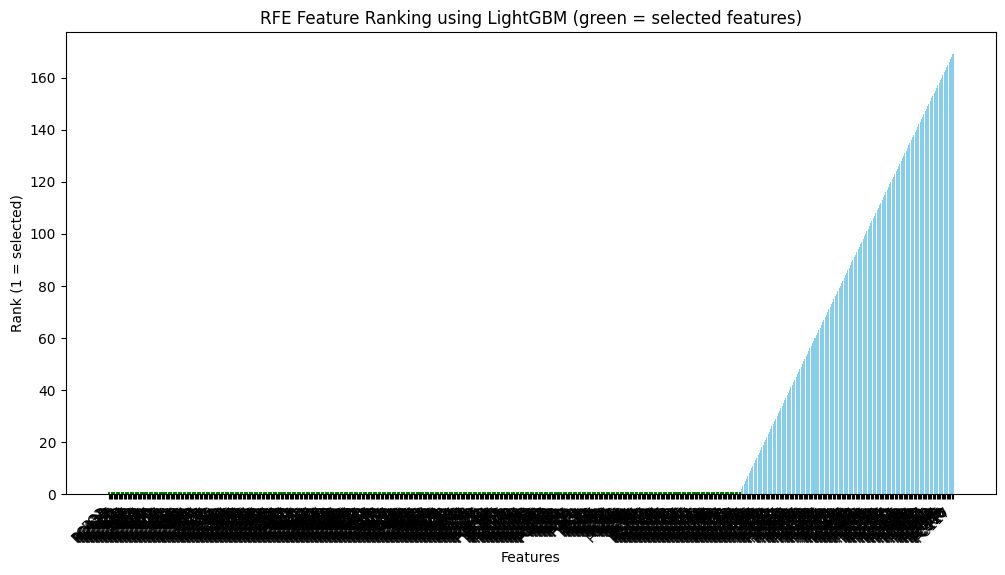

Shape of reduced LightGBM RFE DataFrame: (5965, 500)


In [21]:
## RFE BY LIGHTGBM
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
import lightgbm as lgb

# Features and target
y = df_pca_final['health']
X = df_pca_final.drop(columns=exclude_cols)

# LightGBM classifier
model = lgb.LGBMClassifier(n_estimators=100, random_state=42)

# RFE to select top features (e.g., 500)
rfe = RFE(estimator=model, n_features_to_select=500)
rfe.fit(X, y)

# Create feature ranking DataFrame
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values(by='Ranking')

print("Feature ranking DataFrame:")
print(feature_df)

# Plot feature ranking
plt.figure(figsize=(12,6))
colors = ['green' if sel else 'skyblue' for sel in feature_df['Selected']]
plt.bar(feature_df['Feature'], feature_df['Ranking'], color=colors)
plt.title("RFE Feature Ranking using LightGBM (green = selected features)")
plt.ylabel("Rank (1 = selected)")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.show()

# Create reduced DataFrame with only selected features
df_pca_rfe_final = X[feature_df[feature_df['Selected']]['Feature']].copy()
print("Shape of reduced LightGBM RFE DataFrame:", df_pca_rfe_final.shape)

In [23]:
df_pca_rfe_final_added_id =pd.concat([joined_df[exclude_cols], df_pca_rfe_final], axis=1)

In [24]:
df_pca_rfe_final_added_id.head()

,id,age,health,PC1,PC433,PC432,PC430,PC429,PC428,PC427,...,PC199,PC238,PC275,PC241,PC278,PC222,PC254,PC198,PC197,PC280
0,10317.X00183724.116729,47.9,y,-3.945333,-0.288432,-0.137876,-0.111245,-0.006856,0.289242,0.184415,...,-0.054694,0.046870,-0.043146,-0.114455,0.488344,0.009689,0.287022,-0.041896,0.036656,-0.107133
1,10317.X00185611.139047,49.8,n,-4.676748,-0.004428,0.043750,-0.023177,-0.021171,0.010047,0.001835,...,0.019018,-0.043617,0.098744,0.014928,-0.010733,-0.065882,0.014007,0.039606,-0.060330,-0.086538
2,10317.X00185611.122331,49.8,n,0.320833,-0.297102,0.653203,0.008704,-0.064546,-0.549962,-0.273730,...,-0.702168,0.745410,0.315919,-0.132301,-1.187111,-0.419578,0.830476,-0.293577,0.977767,0.704503
3,10317.X00185611.137612,49.8,n,-4.676748,-0.004428,0.043750,-0.023177,-0.021171,0.010047,0.001835,...,0.019018,-0.043617,0.098744,0.014928,-0.010733,-0.065882,0.014007,0.039606,-0.060330,-0.086538
4,10317.000100524.62408,28.0,y,5.323598,-0.152445,0.822696,0.790724,-0.854221,0.773741,-0.048013,...,-0.166243,-0.526102,0.024562,0.112671,-0.070498,0.154149,0.038086,0.682950,-0.519430,-0.470253


In [26]:
df_pca_rfe_final_added_id.to_csv("DATA_AFTER_FEATURE_SELECTION_PCA_RFE.csv",index=False)